In [1]:
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.combined_pc_kalman_tb import combinedPointCloudKalmanTB
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.movies import MovieGenerator


In [2]:
#setup the datasets
#initial experiments: "/data/radnav/rad_nav_rotate_experiments/wilk_origin_forward/"

dataset = radnavDS(
    dataset_path="/data/radnav/rad_nav_filter_experiments/WILK_BASEMENT_2_WALK/",
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder="/data/radnav/maps",
    map_file="wilk_basement.yaml"
)

found 1307 radar samples
found 1307 lidar samples
found 1307 camera samples
found 1307 imu (orientation only) samples
found 1307imu (full data) samples
found 1307 vehicle velocity samples
loaded map from /data/radnav/maps/wilk_basement.yaml


In [3]:
#initialize the localizers
radar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.3,#originally 0.5
    icp_best_points_percentile=70,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=7, #originally 5
    icp_max_iterations=20,
    self_detection_radius_m=1.0 #originally 0.25
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.6,
    icp_best_points_percentile=50,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=0.25
)

In [4]:
#initialize the test bench
test_bench = combinedPointCloudKalmanTB(
    localizer=radar_odometry,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset
)

start_heading = np.deg2rad(-3.78)
start_pose = np.array([-0.07,-0.13])

new_heading_rad,new_pose_m = test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    show=False
)

loaded map with 16346 points
loaded map with 16346 points
gt icp estimated heading:6.098575847481626 deg, pose:[0.10981328 0.13008615]
radar icp estimated heading:4.947540591660037 deg, pose:[-0.08781469 -0.19956779]


In [5]:
#initialize the kalman filter
start_time_s = test_bench.get_dataset_start_time(idx=0)
print("dataset start time: {}s".format(start_time_s))

test_bench.init_filter(
    est_start_heading_rad=start_heading,
    est_start_position_m=start_pose,
    start_time_s=start_time_s
)

dataset start time: 1718811805.5024607s


found temp dir: /home/david/Downloads/odometry_temp
clearing temp directory /home/david/Downloads/odometry_temp


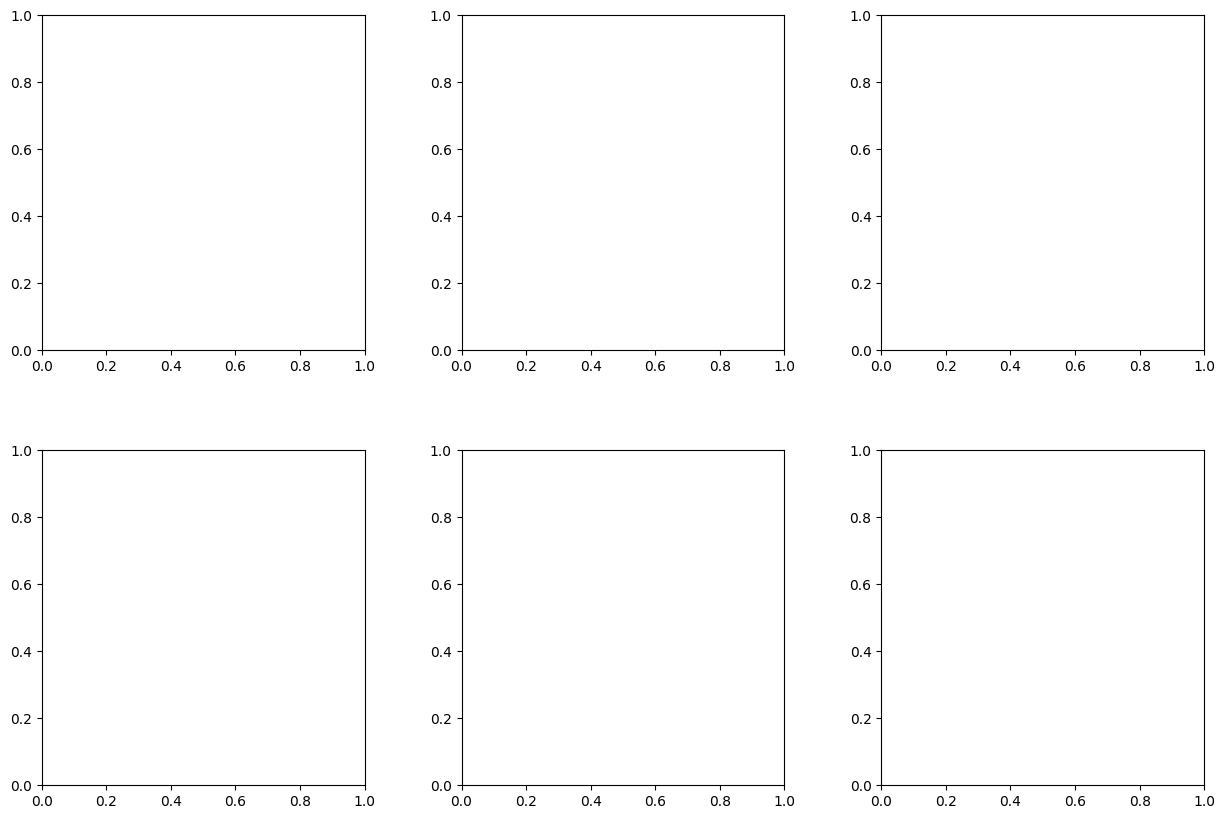

In [6]:
#initialize the movie maker
movie_generator = MovieGenerator(
    temp_dir_path="/home/david/Downloads/odometry_temp"
)
movie_generator.initialize_figure(
    nrows=2,
    ncols=3,
    figsize=(15,10)
)

In [7]:
end_idx = dataset.num_frames
test_bench.run(
    max_frame=end_idx,
    gt_enabled=True,
    movie_generator=None) #=movie_generator)

100%|██████████| 1307/1307 [01:29<00:00, 14.53it/s]


In [8]:
movie_generator.save_movie(video_file_name="wilk_basement_3.mp4",fps=20)

0it [00:00, ?it/s]


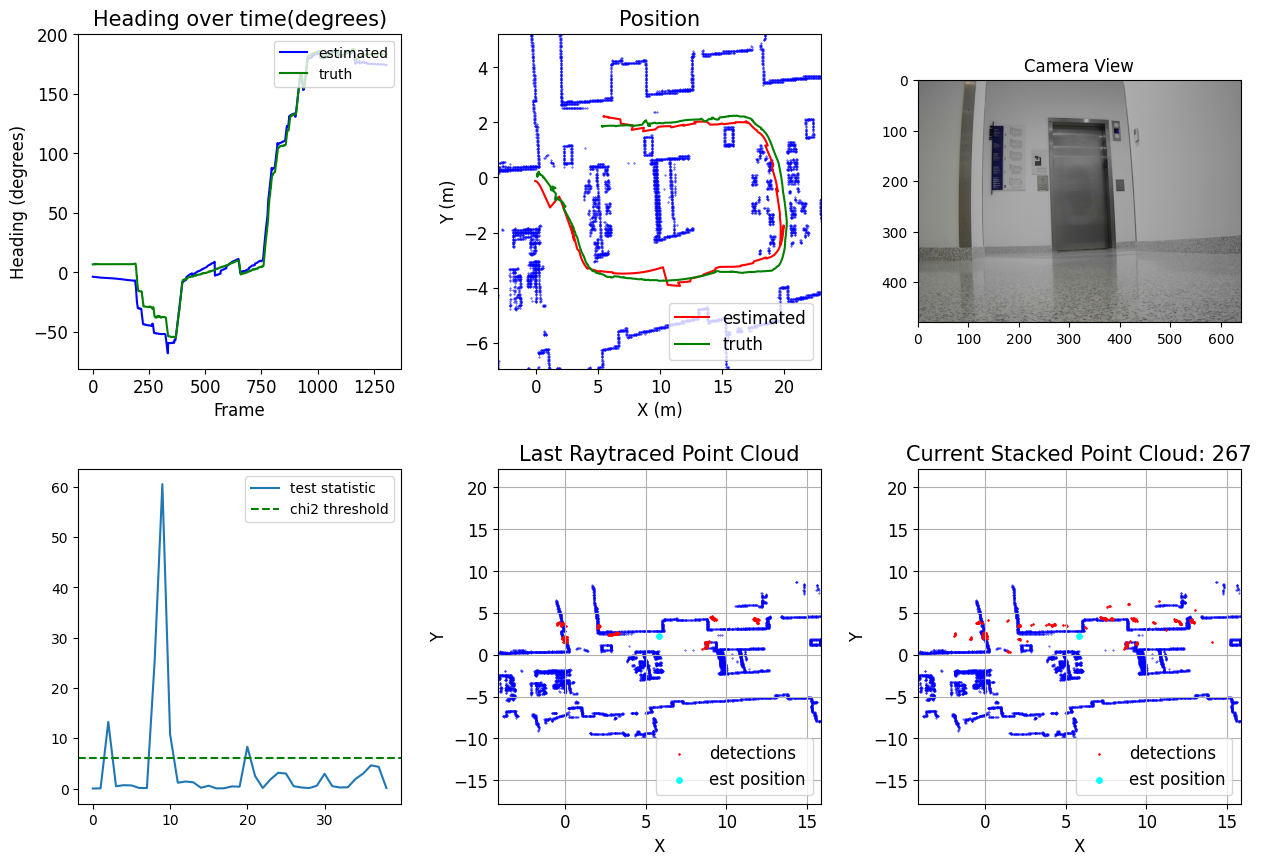

In [9]:
test_bench.plot_compilation(
    idx=end_idx-1,
    show=True
)

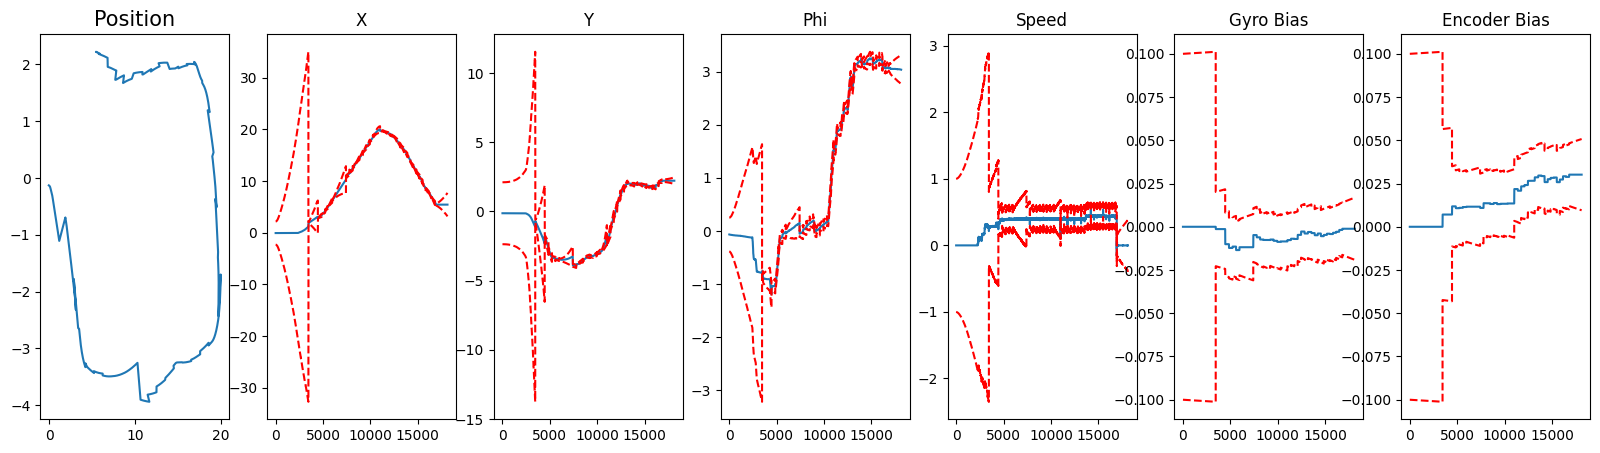

In [10]:
#plot kalman state history
kalman_plotter = PlotterKalman()

kalman_plotter.plot_kalman_result_history(
    x_history=np.array(test_bench.history_filter_est),
    p_history=np.array(test_bench.history_filter_p),
    idx=-1
)

<function matplotlib.pyplot.show(close=None, block=None)>

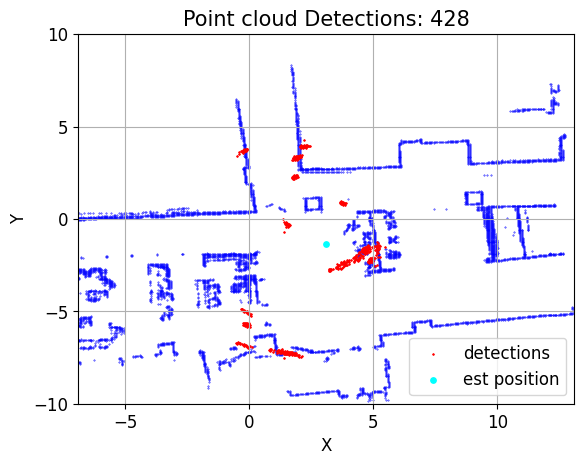

In [11]:
#plotting the saved ray traced point clouds
# plot the lidar point cloud
idx = 1
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=test_bench.history_pc_stacker_point_clouds[idx],
    heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
    pose_m=test_bench.history_pc_stacker_position_m[idx],
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show

In [12]:
test_bench.analyze()

,Metric,Euclidian,x,y,phi
0,Mean,0.330289,0.103518,0.016998,-0.059899
1,Variance,0.015661,0.042784,0.070963,0.015444
2,Median,0.312946,0.166510,0.105484,-0.023752
3,0.9th percentile,0.506400,0.384127,0.399055,0.245544


## Debugging (testing ray tracing)

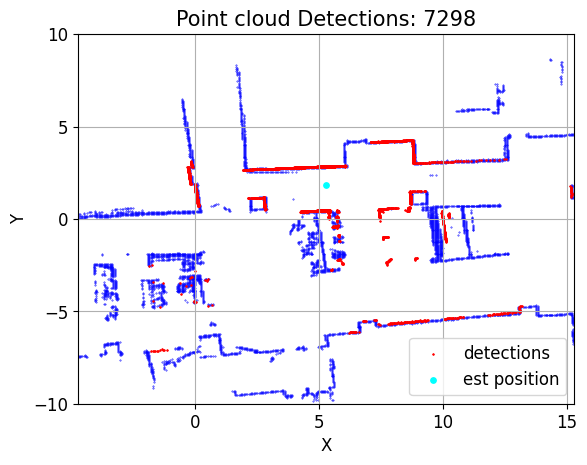

In [13]:
# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.plot_lidar_points_on_map(
    idx=end_idx-1,
    heading_rad=test_bench.gt_localizer.current_heading_rad,
    pose_m=test_bench.gt_localizer.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show()

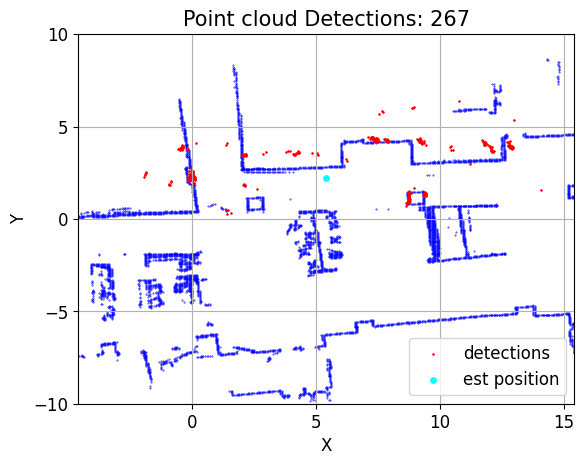

In [14]:
combined_point_cloud = test_bench.point_cloud_stacker.get_points()


# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=combined_point_cloud,
    heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    pose_m=test_bench.point_cloud_stacker.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show()

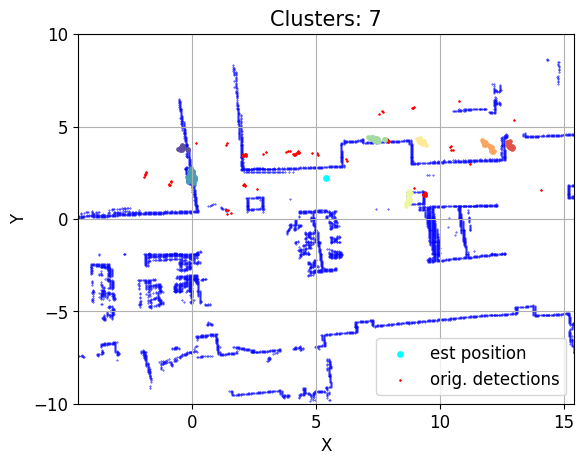

In [15]:
from odometry.point_cloud_processing.multipath import MultiPath
from odometry.supportFns import rotation_functions
from odometry.supportFns import coordinate_systems

stacked_pc_cart = test_bench.point_cloud_stacker.get_points()

multipath = MultiPath(
    clustering_eps=0.3,
    clustering_min_samples=15
)

labels = multipath._cluster_points(stacked_pc_cart)

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detection_clusters_on_map(
    current_points=stacked_pc_cart,
    labels=labels,
    heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    pose_m=test_bench.point_cloud_stacker.current_pose_m,
    ax=ax,
    plot_raw_detections=True,
    show=False
)

ax.set_ylim(-10,10)
plt.show()

In [16]:
from tqdm import tqdm 

for i in tqdm(range(1000)):
    stacked_pc_cart = test_bench.point_cloud_stacker.get_points()
    valid_stacked_pc_cart = multipath.remove_multipath(stacked_pc_cart)

100%|██████████| 1000/1000 [00:02<00:00, 387.56it/s]


<function matplotlib.pyplot.show(close=None, block=None)>

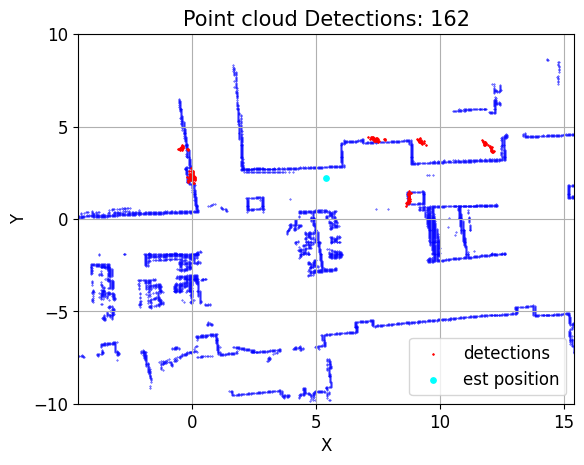

In [17]:
#get the remaining valid points and re-cluster them
valid_stacked_pc_cart = multipath.remove_multipath(stacked_pc_cart)

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=valid_stacked_pc_cart,
    heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    pose_m=test_bench.point_cloud_stacker.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show

Filter estimate: heading: 3.0386586090325807 rad, pose: [5.4285225 2.2197597] m
New estimate: heading: 2.9997019487636774 rad, pose: [5.31250243 2.12514269] m
GT: heading: 3.194274089950391 rad, pose: [5.30741355 1.85830759] m


<function matplotlib.pyplot.show(close=None, block=None)>

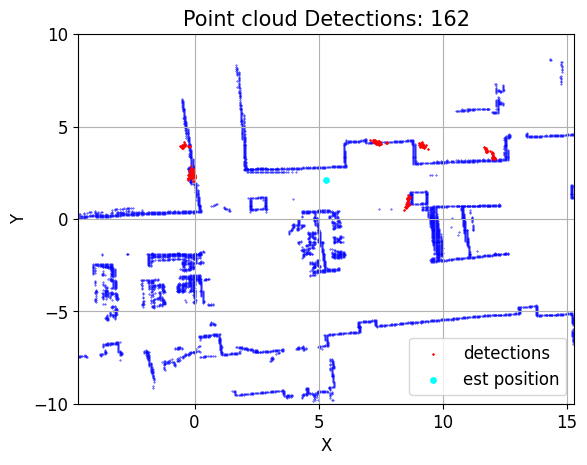

In [18]:
#perform an ICP update

est_heading_rad,est_pose_m = test_bench.localizer.update_odometry(
    points=valid_stacked_pc_cart,
    estimated_heading_rad=test_bench.filter.x[2],
    estimated_pose_m=np.array(
        [test_bench.filter.x[0],
         test_bench.filter.x[1]])
)

print("Filter estimate: heading: {} rad, pose: {} m".format(
    test_bench.filter.x[2],
    np.array(
        [test_bench.filter.x[0],
         test_bench.filter.x[1]])
))
print("New estimate: heading: {} rad, pose: {} m".format(
    est_heading_rad,est_pose_m
))
print("GT: heading: {} rad, pose: {} m".format(
    test_bench.gt_localizer.current_heading_rad,
    test_bench.gt_localizer.current_pose_m
))

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=valid_stacked_pc_cart,
    heading_rad=est_heading_rad,
    pose_m=est_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show